## DVS Project - Image edge detection

Function for converting .jpg to .bin file:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def show_bin_images(file_names: list[str], width: int, height: int, titles: list[str] = None):
    """
    Reads multiple .bin grayscale images from 'images/' or 'processed/' folders
    and displays them side by side with optional titles.
    
    Parameters:
    - file_names: list of .bin file names (e.g., ['img1.bin', 'img2.bin'])
    - width: image width in pixels (same for all images)
    - height: image height in pixels (same for all images)
    - titles: optional list of titles for each image
    """
    search_dirs = ["images", "processed"]
    n = len(file_names)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    
    if n == 1:
        axes = [axes]  # make iterable if only one image
    
    for i, file_name in enumerate(file_names):
        # Find file in one of the search directories
        file_path = None
        for folder in search_dirs:
            candidate = os.path.join(folder, file_name)
            if os.path.exists(candidate):
                file_path = candidate
                break
        if file_path is None:
            raise FileNotFoundError(f"{file_name} not found in {search_dirs}")
        
        # Read image
        with open(file_path, "rb") as f:
            data = f.read()
        
        expected_size = width * height
        if len(data) != expected_size:
            raise ValueError(f"{file_name}: size {len(data)} != expected {expected_size}")
        
        img = np.frombuffer(data, dtype=np.uint8).reshape((height, width))
        
        axes[i].imshow(img, cmap="gray", vmin=0, vmax=255)
        axes[i].axis('off')
        
        if titles and i < len(titles):
            axes[i].set_title(titles[i], fontsize=12)
    
    plt.tight_layout()
    plt.show()

### Test 1

Bypassing 

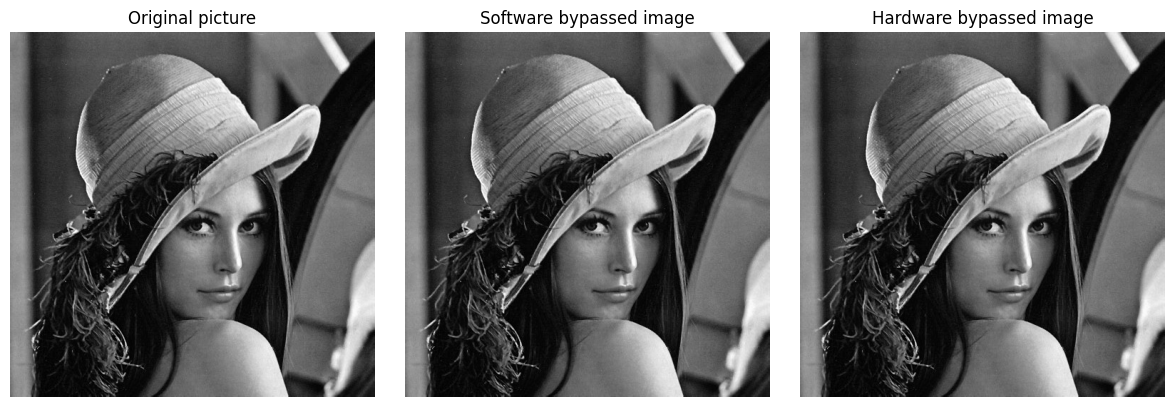

In [2]:
show_bin_images(["lena_512x512.bin", "lena_512x512_bypass_sw.bin", "lena_512x512_bypass_hw.bin"],
                512, 512,
               ["Original picture", "Software bypassed image", "Hardware bypassed image"])

### Test 2
Hroizontal gradient

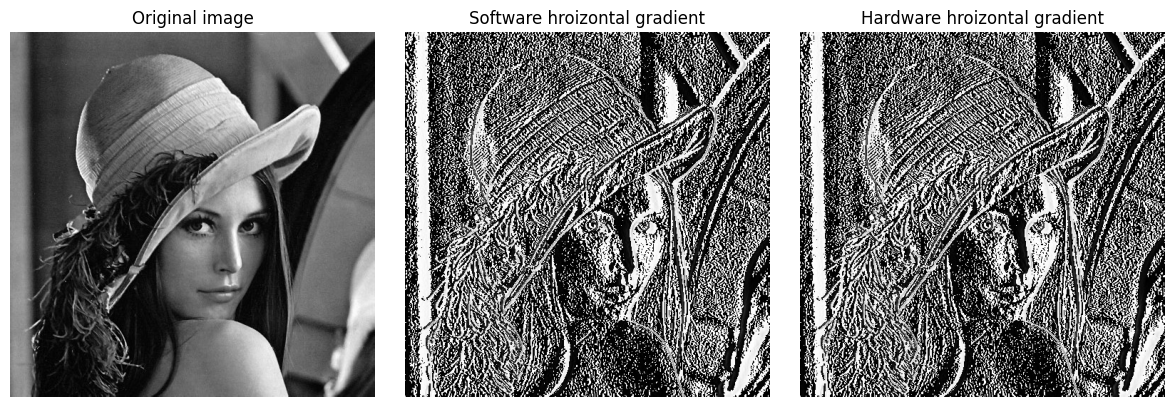

In [3]:
show_bin_images(["lena_512x512.bin", "lena_512x512_gradH_b1_sw.bin", "lena_512x512_gradH_b1_hw.bin"],
                512, 512,
                ["Original image", "Software hroizontal gradient", "Hardware hroizontal gradient"])

### Test 3
Vertical gradient

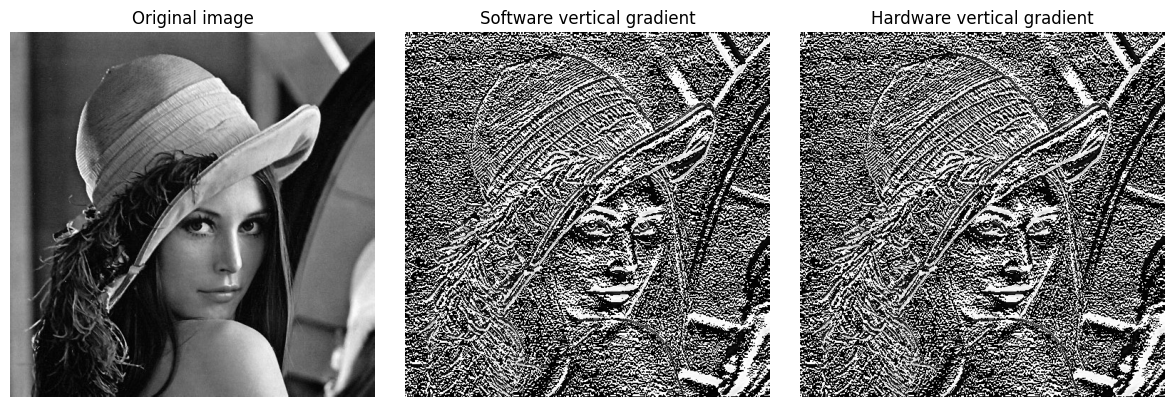

In [4]:
show_bin_images(["lena_512x512.bin", "lena_512x512_gradV_b1_sw.bin", "lena_512x512_gradV_b1_hw.bin"],
                512, 512,
                ["Original image", "Software vertical gradient", "Hardware vertical gradient"])

### Test 4
Magnitude gradient

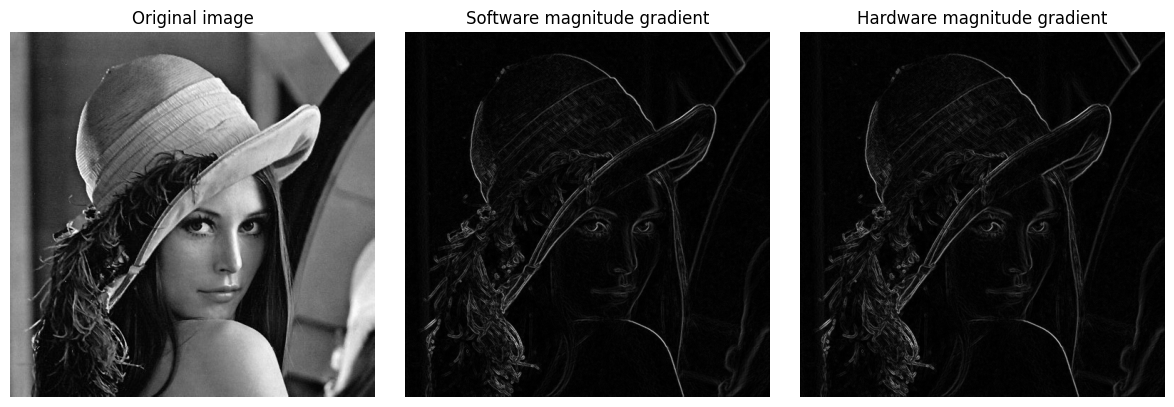

In [5]:
show_bin_images(["lena_512x512.bin", "lena_512x512_gradM_b1_sw.bin", "lena_512x512_gradM_b1_hw.bin"],
                512, 512,
                ["Original image", "Software magnitude gradient", "Hardware magnitude gradient"])

### Test 5
Image edge

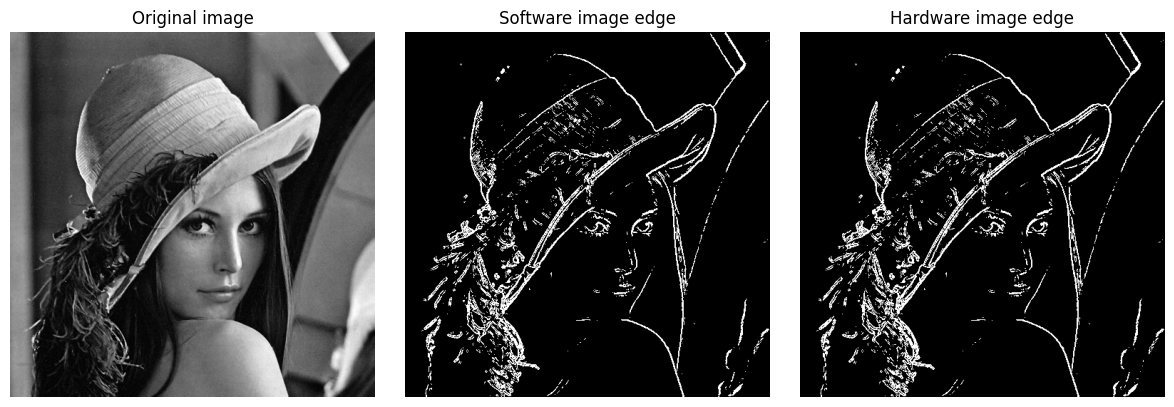

In [6]:
show_bin_images(["lena_512x512.bin", "lena_512x512_edge30_b1_sw.bin", "lena_512x512_edge30_b1_hw.bin"],
                512, 512,
                ["Original image", "Software image edge", "Hardware image edge"])

### Test 6
Testing images with different dimensions

Dock (512x340)

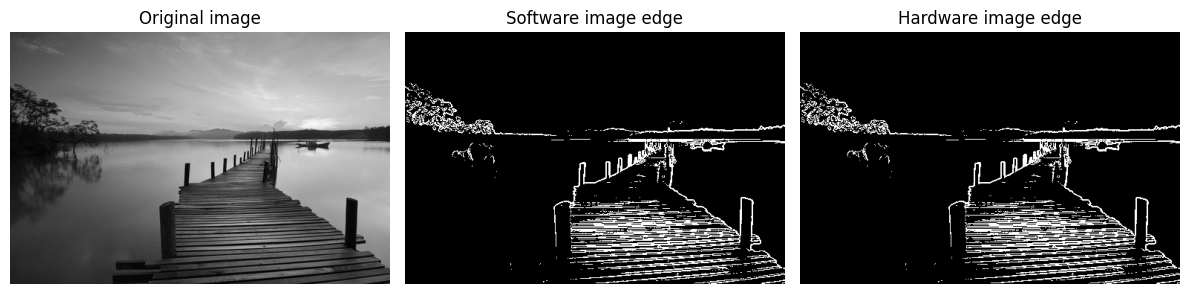

In [7]:
show_bin_images(["dock_512x340.bin", "dock_512x340_edge30_b1_sw.bin", "dock_512x340_edge30_b1_hw.bin"],
                512, 340,
                ["Original image", "Software image edge", "Hardware image edge"])

Puppy (332x300)

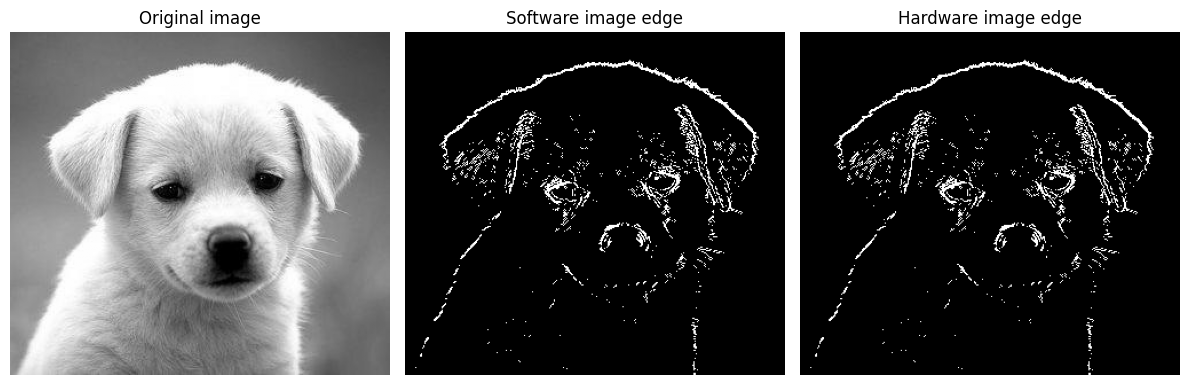

In [8]:
show_bin_images(["puppy_332x300.bin", "puppy_332x300_edge30_b1_sw.bin", "puppy_332x300_edge30_b1_hw.bin"],
                332, 300,
                ["Original image", "Software image edge", "Hardware image edge"])

Sunflower (381x512)

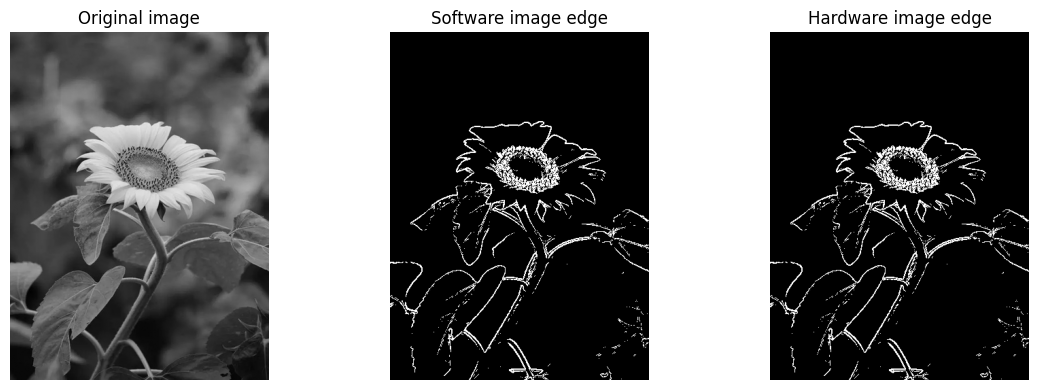

In [9]:
show_bin_images(["sunflower_381x512.bin", "sunflower_381x512_edge30_b1_sw.bin", "sunflower_381x512_edge30_b1_hw.bin"],
                381, 512,
               ["Original image", "Software image edge", "Hardware image edge"])

### Test 7
Testing image with different threshold values

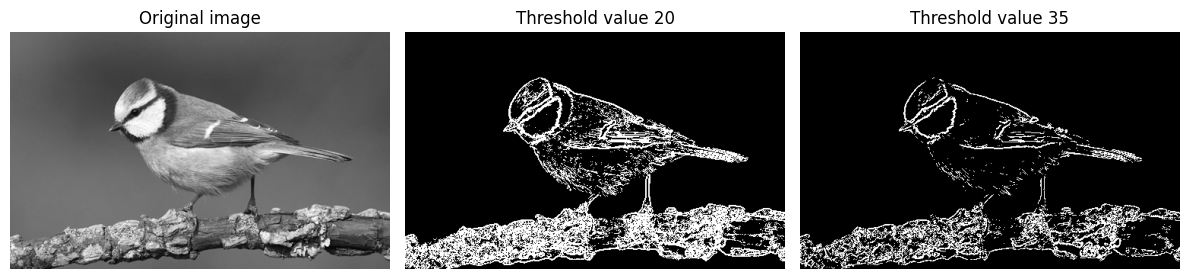

In [10]:
show_bin_images(["bird_500x312.bin", "bird_500x312_edge20_b1_hw.bin", "bird_500x312_edge35_b1_hw.bin"],
                500, 312,
                ["Original image", "Threshold value 20", "Threshold value 35"])

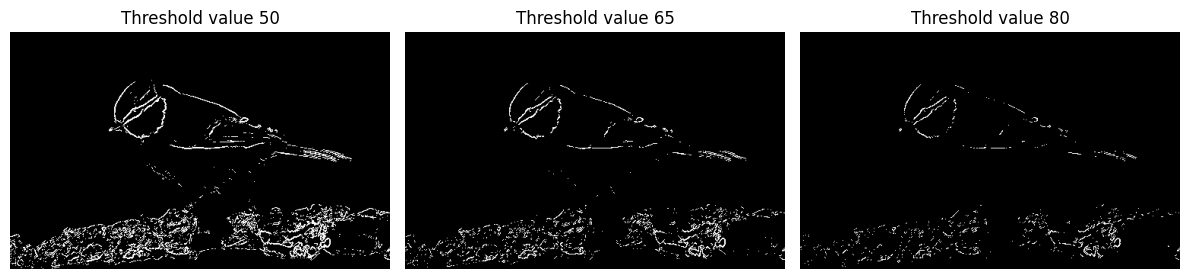

In [11]:
show_bin_images(["bird_500x312_edge50_b1_hw.bin", "bird_500x312_edge65_b1_hw.bin", "bird_500x312_edge80_b1_hw.bin"],
                500, 312,
                ["Threshold value 50", "Threshold value 65", "Threshold value 80"])

### Test 8
Testing image with different border values

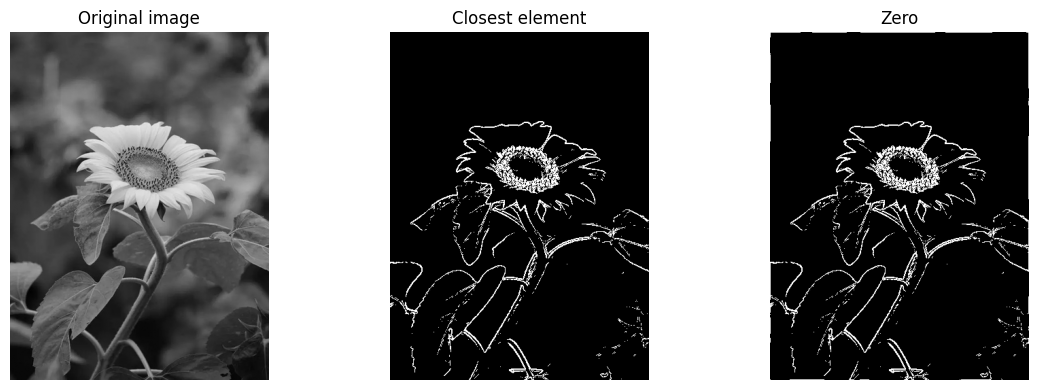

In [12]:
show_bin_images(["sunflower_381x512.bin", "sunflower_381x512_edge30_b1_sw.bin", "sunflower_381x512_edge30_b0_hw.bin"],
                381, 512,
                ["Original image", "Closest element", "Zero"])